In [2]:
# PROYECTO 6: PREDICCIÓN DE DESERCIÓN ESTUDIANTIL
# ANÁLISIS EXPLORATORIO DE DATOS (EDA)


In [3]:
#importacion de librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

In [4]:
#aqui configuramos las visualizaciones
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
print("Librerías importadas correctamente")

Librerías importadas correctamente


In [5]:
#2- aqui cargamos los datos
#Cargar datos de admisión
df_admision = pd.read_csv('../data/processed/conare_admision_limpio.csv')
print("Datos de admisión: {df_admision.shape[0]:,} filas, {df_admision.shape[1]} columnas")

#Cargar datos de matrícula para el modelo
df_matricula_modelo = pd.read_csv('../data/processed/matricula_agregada_modelo.csv')
print("Datos de matrícula modelo: {df_matricula_modelo.shape[0]:,} filas, {df_matricula_modelo.shape[1]} columnas")

#Mostramos las primeras 5 filas
print(" Primeras 5 filas - Admisión:")
df_admision.head()
print("Primeras 5 filas - Matrícula Modelo:")
df_matricula_modelo.head()




Datos de admisión: {df_admision.shape[0]:,} filas, {df_admision.shape[1]} columnas
Datos de matrícula modelo: {df_matricula_modelo.shape[0]:,} filas, {df_matricula_modelo.shape[1]} columnas
 Primeras 5 filas - Admisión:
Primeras 5 filas - Matrícula Modelo:


,AÑO,UNIVERSIDAD,CARRERA,MATRICULADOS,REGION_PLANIFICACION_SEDE,GAM_SEDE,GRADO_ACADEMICO,NIVEL_ACADEMICO,NIVEL_CINE,AREA_CONOCIMIENTO,DISCIPLINA,AREA_UNESCO,DISCIPLINA_UNESCO,STEM_MICITT
0,2021,Tecnológico de Costa Rica,Administración de Empresas,2006,Región Central,GAM,Bachillerato,Grado,CINE 6,Ciencias Económicas,Administración,Administración de Empresas y Derecho,Educación Comercial y Administración,NO STEM
1,2021,Tecnológico de Costa Rica,Administración de Empresas énfasis Administrac...,98,Región Central,GAM,Licenciatura,Grado,CINE 6,Ciencias Económicas,Finanzas,Administración de Empresas y Derecho,Educación Comercial y Administración,NO STEM
2,2021,Tecnológico de Costa Rica,Administración de Empresas énfasis Contaduría ...,46,Región Central,GAM,Licenciatura,Grado,CINE 6,Ciencias Económicas,Contaduría,Administración de Empresas y Derecho,Educación Comercial y Administración,NO STEM
3,2021,Tecnológico de Costa Rica,Administración de Empresas énfasis Mercadeo,53,Región Central,GAM,Licenciatura,Grado,CINE 6,Ciencias Económicas,Mercadeo,Administración de Empresas y Derecho,Educación Comercial y Administración,NO STEM
4,2021,Tecnológico de Costa Rica,Administración de Empresas énfasis Recursos Hu...,1,Región Central,GAM,Licenciatura,Grado,CINE 6,Ciencias Económicas,Administración de Recursos Humanos,Administración de Empresas y Derecho,Educación Comercial y Administración,NO STEM


In [6]:
#3- Analizamos la estructura de datos

print("\n" + "="*60)
print("Estructura de datos - Admision")
print("="*60)

print("\n Información del dataset:")
df_admision.info()

print("\n Columnas disponibles:")
for i, col in enumerate(df_admision.columns, 1):
    print(f"{i}. {col}")

print("\n" + "="*60)
print("Estructura de datos - Matricula Modelo")
print("="*60)

print("\n Información del dataset:")
df_matricula_modelo.info()

print("\n Columnas disponibles:")
for i, col in enumerate(df_matricula_modelo.columns, 1):
    print(f"{i}. {col}")


Estructura de datos - Admision

 Información del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 150084 entries, 0 to 150083
Data columns (total 17 columns):
 #   Column                  Non-Null Count   Dtype
---  ------                  --------------   -----
 0   CONSECUTIVO             150084 non-null  int64
 1   ANO_CONCURSO            150084 non-null  int64
 2   SEXO                    150084 non-null  str  
 3   NACIONALIDAD            150084 non-null  str  
 4   RANGO_EDAD              150084 non-null  str  
 5   PROVINCIA_RESIDENCIA    150084 non-null  str  
 6   CANTON_RESIDENCIA       150084 non-null  str  
 7   SEDE                    150084 non-null  str  
 8   RECINTO                 150084 non-null  str  
 9   RANGO_NOTA_ADMISION     150084 non-null  str  
 10  TIPO_COLEGIO            150084 non-null  str  
 11  TIPO_HORARIO_COLEGIO    150084 non-null  str  
 12  TIPO_MODALIDAD_COLEGIO  150084 non-null  str  
 13  PROVINCIA_COLEGIO       150025 non-null  str  
 14  CANT

In [7]:
#4-Estadisticas descriptivas

print("\n" + "="*60)
print("Estadisticas descriptivas")
print("="*60)

print("\n Estadísticas - Admisión:")
df_admision.describe()

print("\n Estadísticas - Matrícula Modelo:")
df_matricula_modelo.describe()


Estadisticas descriptivas

 Estadísticas - Admisión:

 Estadísticas - Matrícula Modelo:


,AÑO,MATRICULADOS
count,3047.000000,3047.000000
mean,2022.957663,199.208074
std,1.420183,498.538378
min,2021.000000,1.000000
25%,2022.000000,8.000000
50%,2023.000000,29.000000
75%,2024.000000,200.000000
max,2025.000000,7598.000000


In [8]:
# 5-  Calidad de datos, vemos los valores nulos o duplicados

print("\n" + "="*60)
print("Calidad de datos")
print("="*60)

# aqui tenemos los valores nulos de admision
nulos_admision = df_admision.isnull().sum()
nulos_admision = nulos_admision[nulos_admision > 0].sort_values(ascending=False)

if len(nulos_admision) > 0:
    print("\n Valores nulos - Admisión:")
    for col, val in nulos_admision.items():
        print(f"  {col}: {val:,} ({val/len(df_admision)*100:.2f}%)")
else:
    print("\n No hay valores nulos en datos de admisión")

# Valores nulos de matrícula modelo
nulos_matricula = df_matricula_modelo.isnull().sum()
nulos_matricula = nulos_matricula[nulos_matricula > 0].sort_values(ascending=False)

if len(nulos_matricula) > 0:
    print("\n Valores nulos - Matrícula Modelo:")
    for col, val in nulos_matricula.items():
        print(f"  {col}: {val:,} ({val/len(df_matricula_modelo)*100:.2f}%)")
else:
    print("\n No hay valores nulos en datos de matrícula modelo")

# Datos duplicados
duplicados_admision = df_admision.duplicated().sum()
duplicados_matricula = df_matricula_modelo.duplicated().sum()

print(f"\n Filas duplicadas - Admisión: {duplicados_admision:,}")
print(f" Filas duplicadas - Matrícula Modelo: {duplicados_matricula:,}")


Calidad de datos

 Valores nulos - Admisión:
  PROVINCIA_COLEGIO: 59 (0.04%)
  CANTON_COLEGIO: 59 (0.04%)

 No hay valores nulos en datos de matrícula modelo

 Filas duplicadas - Admisión: 0
 Filas duplicadas - Matrícula Modelo: 0


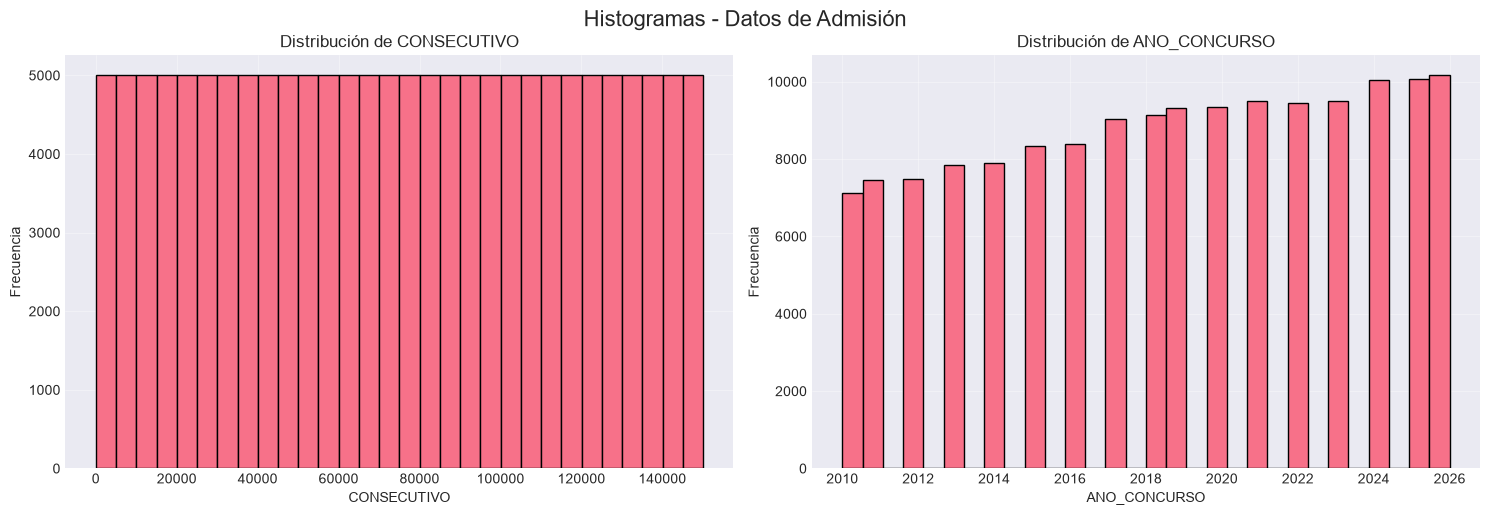

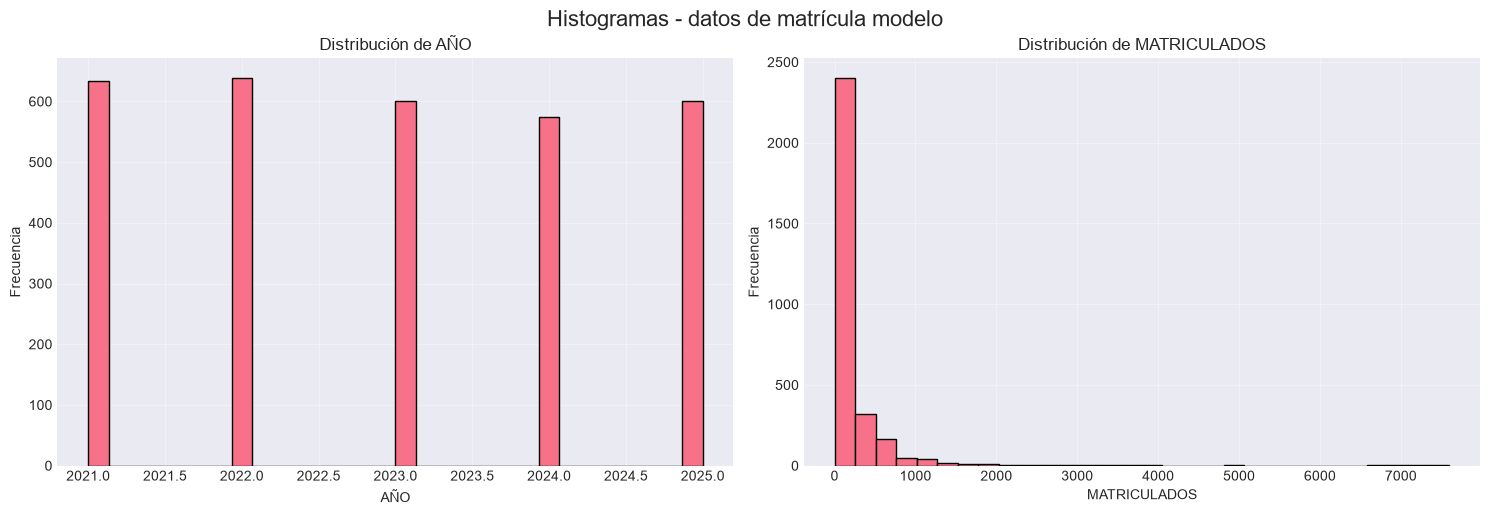

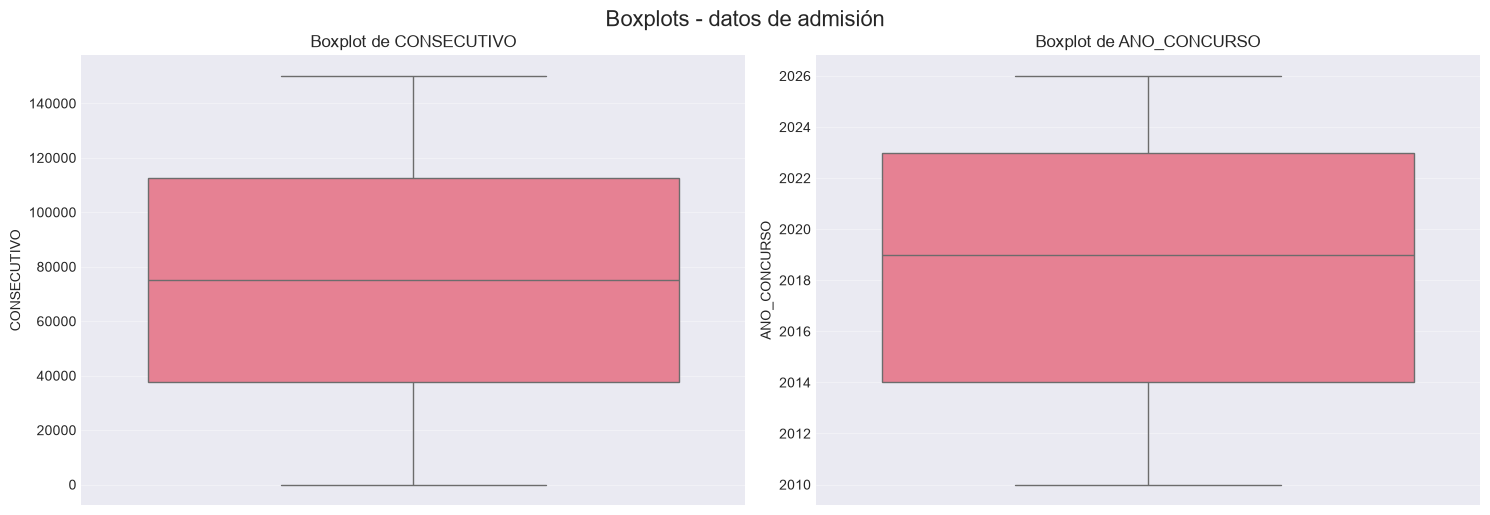

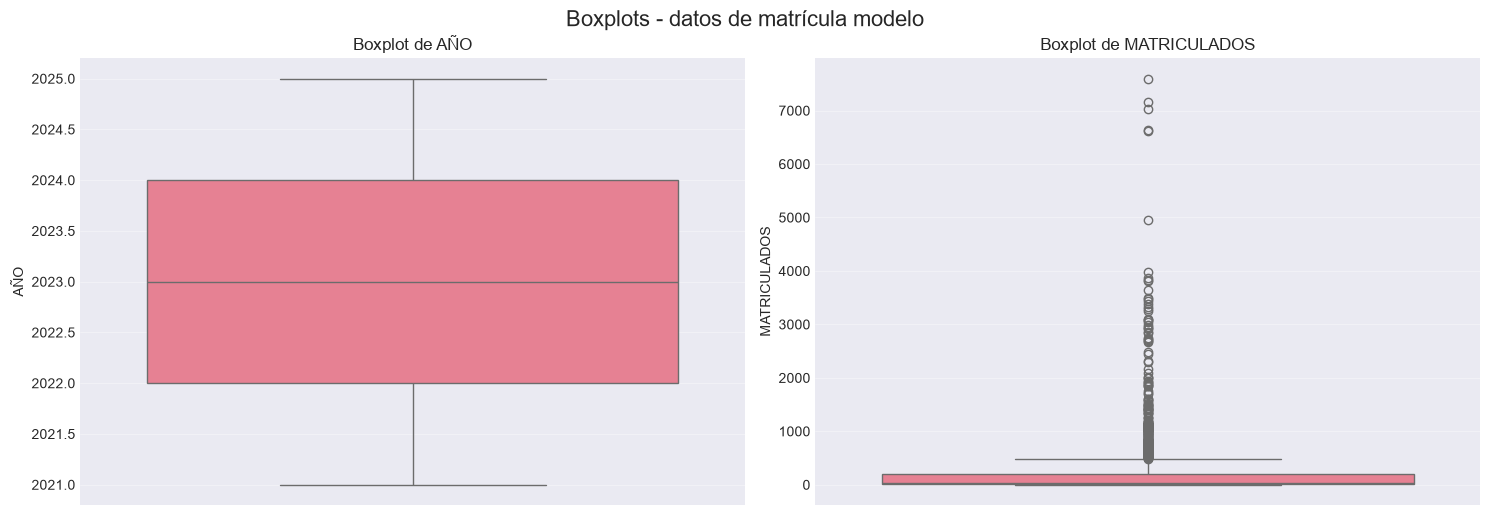

In [14]:
import math
def plot_grid(df, cols, kind, title):
    n = len(cols)
    if n == 0:
        return
    ncols = 2
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 5 * nrows))
    axes = axes.flatten() if n > 1 else [axes]

    for i, col in enumerate(cols[:8]):
        if kind == 'hist':
            df[col].hist(bins=30, ax=axes[i], edgecolor='black')
            axes[i].set_xlabel(col)
            axes[i].set_ylabel('Frecuencia')
            axes[i].set_title(f'Distribución de {col}', fontsize=12)
        elif kind == 'box':
            sns.boxplot(y=df[col], ax=axes[i])
            axes[i].set_title(f'Boxplot de {col}', fontsize=12)

    for j in range(n, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.suptitle(title, fontsize=16, y=1.02)
    plt.show()


# Histogramas
plot_grid(df_admision, list(num_cols_admision), 'hist', 'Histogramas - Datos de Admisión')
plot_grid(df_matricula_modelo, list(num_cols_matricula), 'hist', 'Histogramas - datos de matrícula modelo')

# Boxplots
plot_grid(df_admision, list(num_cols_admision), 'box', 'Boxplots - datos de admisión')
plot_grid(df_matricula_modelo, list(num_cols_matricula), 'box', 'Boxplots - datos de matrícula modelo')


Analisis de matriz de correlacion


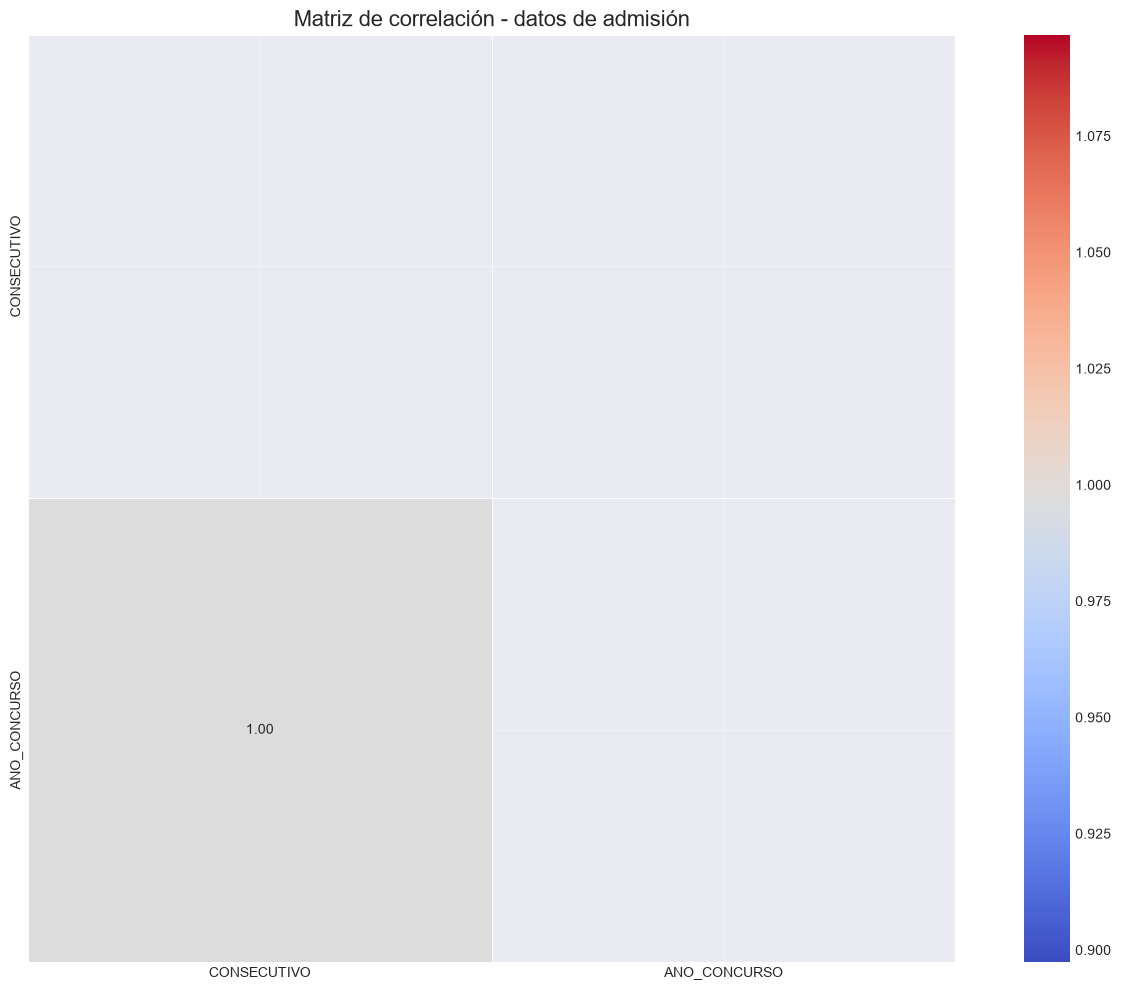

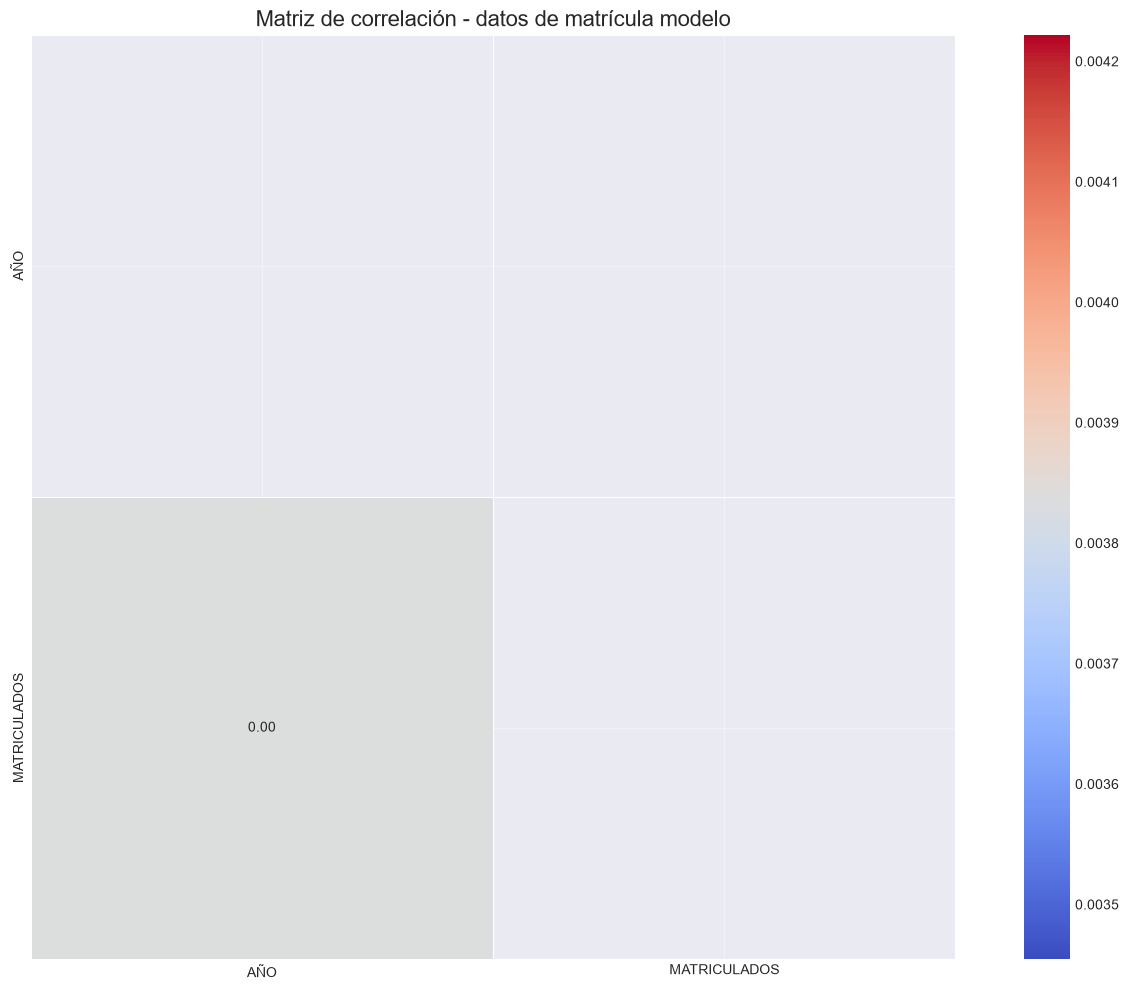

In [10]:
# 7-Analisis de matriz de correlacion

print("\n" + "="*60)
print("Analisis de matriz de correlacion")
print("="*60)

# Matriz de correlación - Admisión
if len(num_cols_admision) > 1:
    plt.figure(figsize=(14, 10))
    corr_admision = df_admision[num_cols_admision].corr()
    mask = np.triu(np.ones_like(corr_admision, dtype=bool))
    sns.heatmap(corr_admision, mask=mask, annot=True, cmap='coolwarm',
                fmt='.2f', linewidths=0.5, square=True)
    plt.title('Matriz de correlación - datos de admisión', fontsize=16)
    plt.tight_layout()
    plt.show()

# Matriz de correlación - Matrícula modelo
if len(num_cols_matricula) > 1:
    plt.figure(figsize=(14, 10))
    corr_matricula = df_matricula_modelo[num_cols_matricula].corr()
    mask = np.triu(np.ones_like(corr_matricula, dtype=bool))
    sns.heatmap(corr_matricula, mask=mask, annot=True, cmap='coolwarm',
                fmt='.2f', linewidths=0.5, square=True)
    plt.title('Matriz de correlación - datos de matrícula modelo', fontsize=16)
    plt.tight_layout()
    plt.show()

In [ ]:
# Las dos correlaciones son correctas, se ven extranas porque son de 2x2 , pero es porque solo hay dos columnas numericas, otro detalle importante,consecutivo tiene "150,084" valores únicos casi iguales a la cantidad de filas,eso significa que es un ID, no una variable real. Correlacionar un ID con otra cosa no tiene ningún significado estadístico.En la segunda imagen tambien es un resultado real,significa que casi no hay correlación lineal entre el año y la cantidad de matriculados

In [11]:
# 8- Analisis de variables categoricas

print("\n" + "="*60)
print("Analisis de variables categoricas")
print("="*60)

cat_cols_admision = df_admision.select_dtypes(include=['object']).columns
cat_cols_matricula = df_matricula_modelo.select_dtypes(include=['object']).columns

if len(cat_cols_admision) > 0:
    print(f"\n Variables categóricas - Admisión: {list(cat_cols_admision)}")
    for col in cat_cols_admision[:3]:
        print(f"\n Distribución de {col}:")
        print(df_admision[col].value_counts().head(10))

if len(cat_cols_matricula) > 0:
    print(f"\n Variables categóricas - Matrícula Modelo: {list(cat_cols_matricula)}")
    for col in cat_cols_matricula[:3]:
        print(f"\n Distribución de {col}:")
        print(df_matricula_modelo[col].value_counts().head(10))


Analisis de variables categoricas

 Variables categóricas - Admisión: ['SEXO', 'NACIONALIDAD', 'RANGO_EDAD', 'PROVINCIA_RESIDENCIA', 'CANTON_RESIDENCIA', 'SEDE', 'RECINTO', 'RANGO_NOTA_ADMISION', 'TIPO_COLEGIO', 'TIPO_HORARIO_COLEGIO', 'TIPO_MODALIDAD_COLEGIO', 'PROVINCIA_COLEGIO', 'CANTON_COLEGIO', 'TIPO_PROCESO_ADMISION', 'CARRERA']

 Distribución de SEXO:
SEXO
MUJER     76952
HOMBRE    73132
Name: count, dtype: int64

 Distribución de NACIONALIDAD:
NACIONALIDAD
NACIONAL      146305
EXTRANJERA      3779
Name: count, dtype: int64

 Distribución de RANGO_EDAD:
RANGO_EDAD
19 o 20       64724
18 o menos    63798
21 o 22       12084
25 o más       5018
23 o 24        4460
Name: count, dtype: int64

 Variables categóricas - Matrícula Modelo: ['UNIVERSIDAD', 'CARRERA', 'REGION_PLANIFICACION_SEDE', 'GAM_SEDE', 'GRADO_ACADEMICO', 'NIVEL_ACADEMICO', 'NIVEL_CINE', 'AREA_CONOCIMIENTO', 'DISCIPLINA', 'AREA_UNESCO', 'DISCIPLINA_UNESCO', 'STEM_MICITT']

 Distribución de UNIVERSIDAD:
UNIVERSIDAD
Un